Reading data: LDC2_spritz_mbhb1_training_v1.h5
Data length: 535680, Sampling rate: 0.2 Hz, Sampling interval: 5.0 s, Total duration: 31.00 days
Performing time-frequency transform (WDM Approximation)...


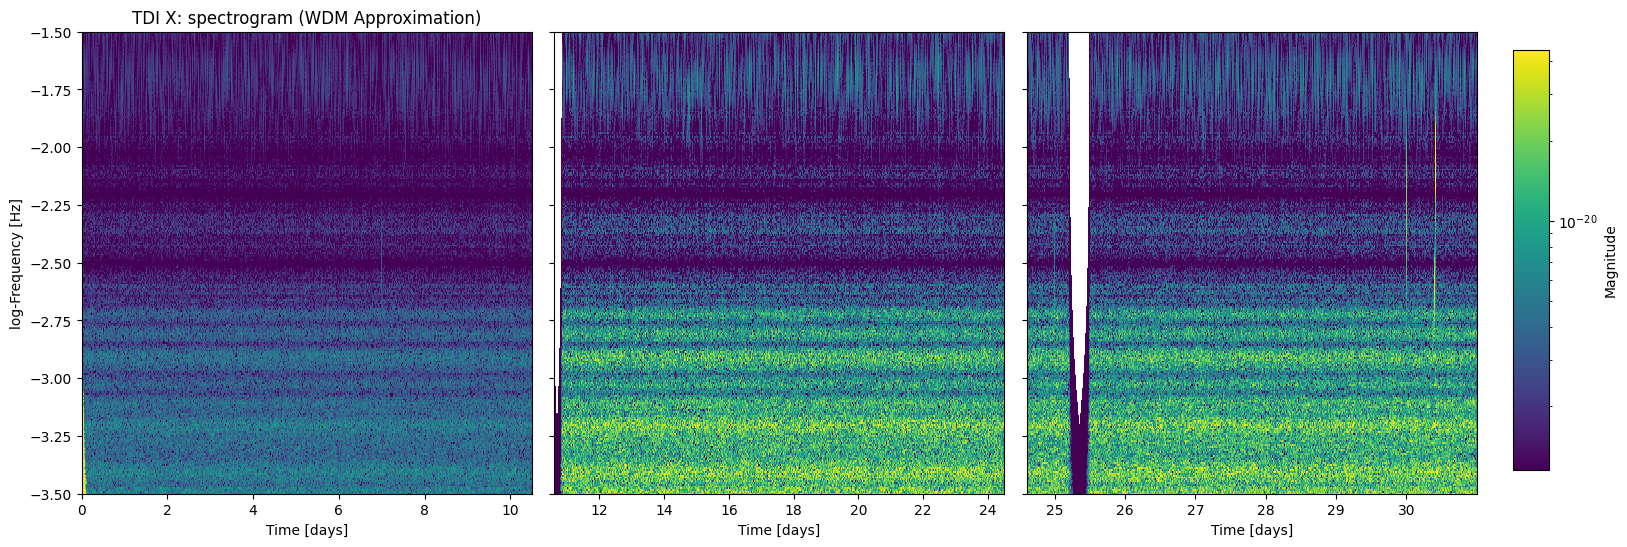

Performing FRFT analysis...


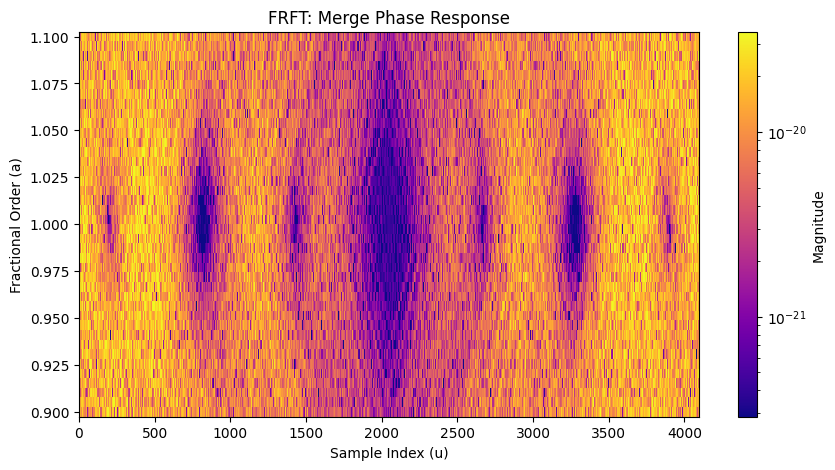

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

try:
    import pywt
except ImportError:
    print("please pip install PyWavelets")

def pure_numpy_frft(x, a):
    N = len(x)
    alpha = a * np.pi / 2.0
    if np.abs(np.sin(alpha)) < 1e-10:
        return x if np.cos(alpha) > 0 else np.flip(x)
    t = np.arange(N) - N // 2
    u = np.arange(N) - N // 2
    T, U = np.meshgrid(t, u)
    cot_a = 1.0 / np.tan(alpha)
    csc_a = 1.0 / np.sin(alpha)
    kernel = np.exp(1j * np.pi * ((T**2 + U**2) * cot_a - 2 * T * U * csc_a) / N)
    return np.dot(kernel, x) / np.sqrt(N)

def perfect_task_solution(file_path):
    # ==========================================
    # 1. Read data and calibrate sampling rate
    # ==========================================
    print(f"Reading data: {file_path}")
    with h5py.File(file_path, 'r') as f:
        raw_data = f['obs/tdi']['X'][:]
        data = np.nan_to_num(raw_data.flatten(), nan=0.0)
        
        # Extract real sampling interval (LISA data is usually 5s)
        dt = f['obs/tdi'].attrs.get('dt', 5.0)

    fs = 1.0 / dt
    data_len = len(data)
    t_seconds = np.arange(data_len) * dt
    t_days = t_seconds / (24 * 3600)

    print(f"Data length: {data_len}, Sampling rate: {fs} Hz, "
          f"Sampling interval: {dt} s, Total duration: {t_days[-1]:.2f} days")

    # ==========================================
    # 2. WDM approximation using Complex Morlet CWT
    # ==========================================
    print("Performing time-frequency transform (WDM Approximation)...")

    # Frequency range required by the task: 10^-3.5 \~ 10^-1.5 Hz
    f_min, f_max = 10**(-3.5), 10**(-1.5)
    frequencies = np.logspace(np.log10(f_min), np.log10(f_max), 256)

    # Use complex Morlet wavelet to better approximate WDM
    wavelet_name = 'cmor1.5-1.0'

    # Calculate scales
    center_freq = pywt.central_frequency(wavelet_name, precision=8)
    scales = (center_freq * fs) / frequencies

    # Perform Continuous Wavelet Transform (CWT)
    coef, freqs_cwt = pywt.cwt(data, scales, wavelet_name, sampling_period=dt)
    magnitude = np.abs(coef)

    # ==========================================
    # 3. Plotting - Three-panel spectrogram
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    plt.subplots_adjust(wspace=0.05)

    intervals = [(0, 10.5), (10.6, 24.5), (24.6, 31)]

    for i, (d_start, d_end) in enumerate(intervals):
        mask = (t_days >= d_start) & (t_days <= d_end)
        if not np.any(mask):
            continue

        seg_mag = magnitude[:, mask]

        # Percentile clipping to suppress background noise
        vmin = np.percentile(seg_mag, 20)
        vmax = np.percentile(seg_mag, 99.8)

        mesh = axes[i].pcolormesh(
            t_days[mask],
            np.log10(frequencies),
            seg_mag,
            shading='auto',
            cmap='viridis',
            norm=LogNorm(vmin=vmin, vmax=vmax)
        )

        axes[i].set_xlabel('Time [days]')
        if i == 0:
            axes[i].set_ylabel('log-Frequency [Hz]')
            axes[i].set_title('TDI X: spectrogram (WDM Approximation)')
        axes[i].set_ylim([np.log10(f_min), np.log10(f_max)])

    # Add colorbar on the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(mesh, cax=cbar_ax, label='Magnitude')
    plt.show()

    # =========================================
    # 4. FRFT Analysis
    # =========================================
    print("Performing FRFT analysis...")

    slice_size = 4096
    signal_slice = data[-slice_size:]
    signal_slice = signal_slice - np.mean(signal_slice)

    a_values = np.linspace(0.9, 1.1, 40)
    frft_matrix = np.zeros((len(a_values), slice_size))

    for idx, a in enumerate(a_values):
        F_a = pure_numpy_frft(signal_slice, a)
        frft_matrix[idx, :] = np.abs(F_a)

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(
        np.arange(slice_size),
        a_values,
        frft_matrix,
        shading='auto',
        cmap='plasma',
        norm=LogNorm(vmin=np.percentile(frft_matrix, 1), vmax=np.percentile(frft_matrix, 99))
    )
    plt.colorbar(label='Magnitude')
    plt.ylabel('Fractional Order (a)')
    plt.xlabel('Sample Index (u)')
    plt.title('FRFT: Merge Phase Response')
    plt.show()


if __name__ == "__main__":
    file_path = 'LDC2_spritz_mbhb1_training_v1.h5'
    try:
        perfect_task_solution(file_path)
    except Exception as e:
        print(f"Error: {e}")
